<a href="https://colab.research.google.com/github/DiyaSrivastava295/house-price-prediction-ml/blob/main/house_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
# House Price Prediction model using regression, compareing two model i.e Linear Regression and Random Forest

import pandas as pd
import numpy as np

import os

# creating folder for plots
os.makedirs("plots", exist_ok=True)

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score )

# Ignoring warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Random seed
SEED = 42

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')

print("No error.")

No error.


In [34]:
# Loading dataset
housing = fetch_california_housing(as_frame=True)

df = housing.frame.copy()

print(f"Dataset shape: {df.shape}")

# checking basic statistics

df.describe().round(2)

#first few rows

df.head()

Dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [35]:
# Checking missing values

missing = df.isnull().sum()
print(missing)

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


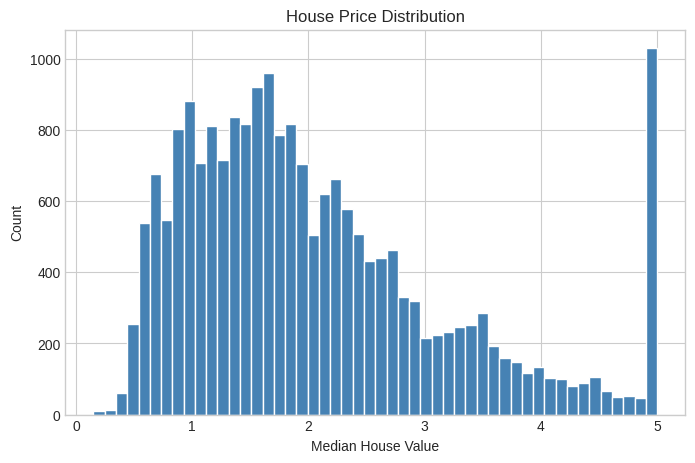

In [36]:
# House price distribution

plt.figure(figsize=(8,5))

plt.hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='white')

plt.title('House Price Distribution')
plt.xlabel('Median House Value')
plt.ylabel('Count')

plt.savefig('plots/01_target_distribution.png')
plt.show()

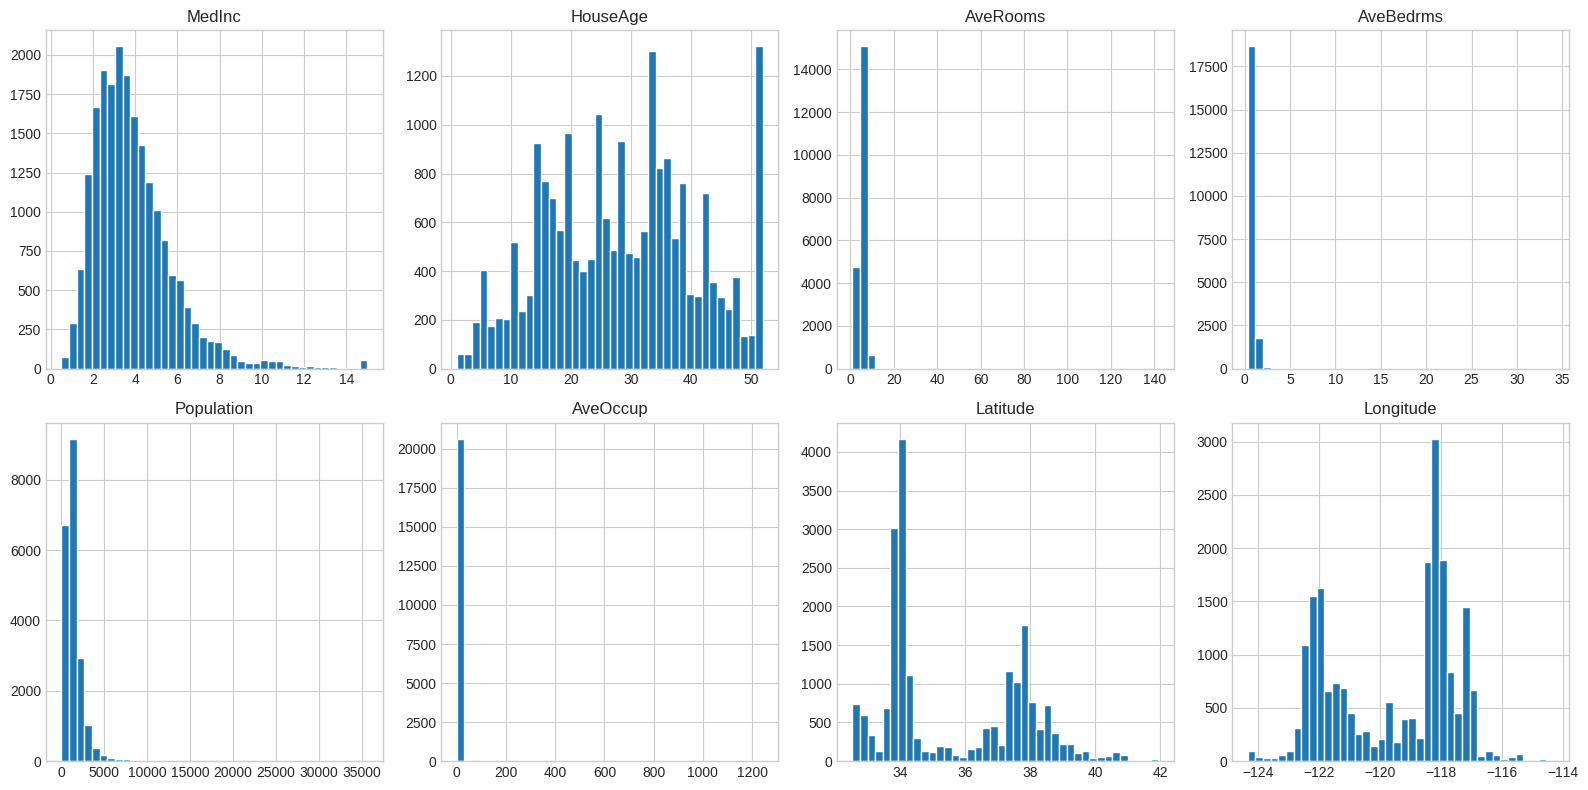

In [37]:
# Feature Distributions

# feature distributions

feature_cols = [c for c in df.columns if c != 'MedHouseVal']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=40, edgecolor='white')
    axes[i].set_title(col)

plt.tight_layout()

plt.savefig('plots/02_feature_distributions.png')
plt.show()

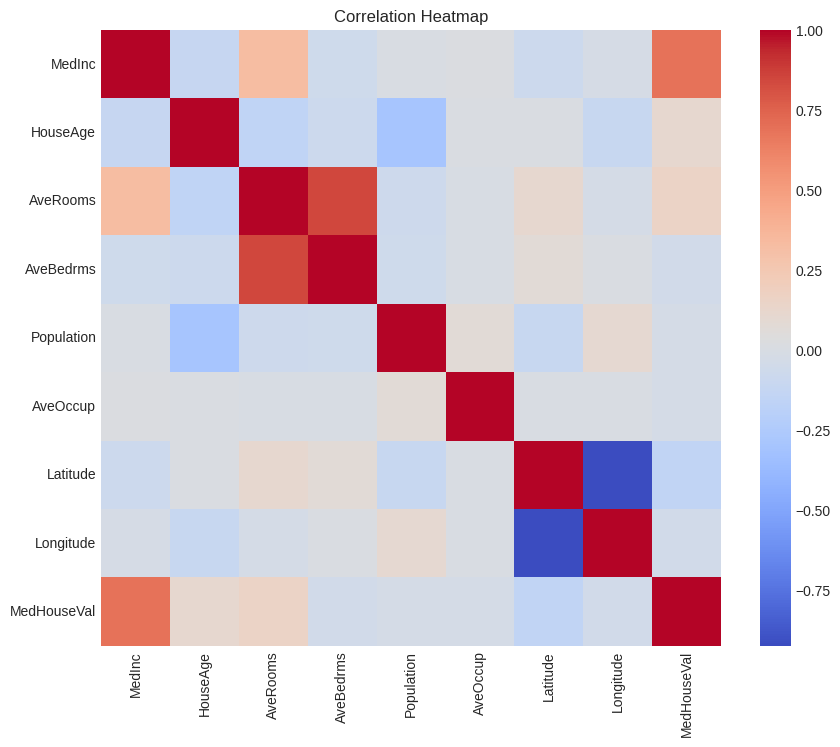

,MedHouseVal
MedInc,0.688075
HouseAge,0.105623
AveRooms,0.151948
AveBedrms,-0.046701
Population,-0.024650
AveOccup,-0.023737
Latitude,-0.144160
Longitude,-0.045967
MedHouseVal,1.000000


In [38]:
# Correlation Heatmap
#   +1.0 = perfect positive relationship
#   -1.0 = perfect negative relationship
#    0.0 = no relationship

corr_matrix = df.corr()

plt.figure(figsize=(10,8))

sns.heatmap(corr_matrix, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.savefig('plots/03_correlation_heatmap.png')
plt.show()

# correlation with target
corr_matrix['MedHouseVal']

In [39]:
# separating features and target

X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# splitting train and test data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED
)

print(X_train.shape, X_test.shape)

(16512, 8) (4128, 8)


In [40]:
# scaling features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
# linear regression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [42]:
# random forest

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=SEED
)

rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

In [43]:
# model evaluation

def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }

results_lr = evaluate_model(y_test, y_pred_lr)
results_rf = evaluate_model(y_test, y_pred_rf)

print("Linear Regression:", results_lr)
print("Random Forest:", results_rf)

Linear Regression: {'MAE': 0.5332001304956565, 'RMSE': np.float64(0.7455813830127763), 'R2': 0.575787706032451}
Random Forest: {'MAE': 0.3331576559523984, 'RMSE': np.float64(0.5113235229945103), 'R2': 0.8004808044596186}


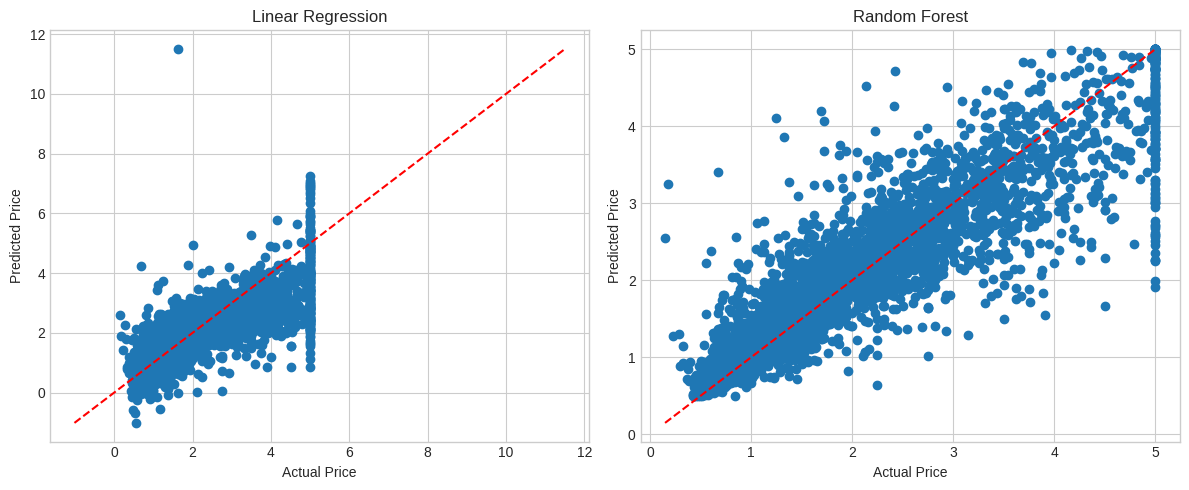

In [44]:
# actual vs predicted values

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, y_pred) in zip(axes, [
    ('Linear Regression', y_pred_lr),
    ('Random Forest', y_pred_rf)
]):

    ax.scatter(y_test, y_pred)

    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())

    ax.plot([min_val, max_val], [min_val, max_val], 'r--')

    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.set_title(name)

plt.tight_layout()

plt.savefig('plots/04_actual_vs_predicted.png')

plt.show()

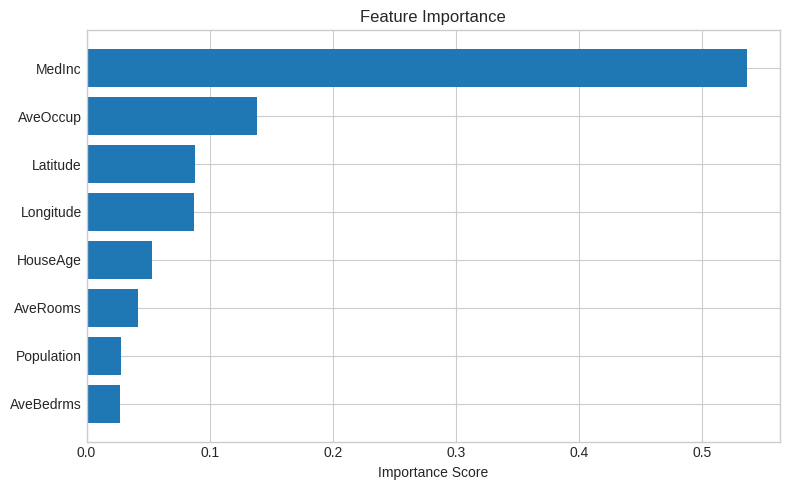

,Feature,Importance
0,MedInc,0.536359
5,AveOccup,0.138692
6,Latitude,0.087856


In [45]:
# feature importance

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8,5))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xlabel('Importance Score')
plt.title('Feature Importance')

plt.tight_layout()

plt.savefig('plots/05_feature_importance.png')

plt.show()

importance_df.sort_values('Importance', ascending=False).head(3)

In [46]:
# comparing model performance

summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [
        round(results_lr['MAE'], 4),
        round(results_rf['MAE'], 4)
    ],
    'RMSE': [
        round(results_lr['RMSE'], 4),
        round(results_rf['RMSE'], 4)
    ],
    'R2 Score': [
        round(results_lr['R2'], 4),
        round(results_rf['R2'], 4)
    ]
})

summary

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.5332,0.7456,0.5758
1,Random Forest,0.3332,0.5113,0.8005
